In [1]:
# ==========================
# 项目基础环境配置模块
# 功能：统一加载第三方依赖库、全局绘图样式、日志与数据接口初始化
# 提供兼容聚宽/通达信/Tushare 的基础工具接口
# ==========================
import pandas as pd
import numpy as np
import scipy.stats as stats
import datetime as datetime_pkg
from dateutil.parser import parse as date_parse
import itertools

from alphalens.utils import print_table
from tqdm import tqdm
import pickle
import json

from jqdata import *
from jqfactor import *
import talib

import tushare as tushare_api

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

# ==========================
# Tushare 自动重试封装类
# 功能：提供超时自动等待、无限重试机制，提升数据下载稳定性
# ==========================
class TushareDataService:
    """
    Tushare数据接口增强封装
    支持异常自动重试、日志记录、超时等待
    """
    def __init__(self, api_token, log_instance=None, max_retry_times=0):
        self.api_token = api_token
        self.max_retry_times = max_retry_times

        if log_instance is None:
            log_instance = logging.getLogger('TushareDataService')
            log_instance.setLevel(logging.DEBUG)
            log_format = logging.Formatter(
                '%(asctime)s %(name)s %(pathname)s:%(lineno)d %(funcName)s %(levelname)s %(message)s'
            )
            stream_handler = logging.StreamHandler()
            stream_handler.setFormatter(log_format)
            stream_handler.setLevel(logging.DEBUG)
            log_instance.addHandler(stream_handler)

        self.log_instance = log_instance
        tushare_api.set_token(api_token)
        self.pro_api = tushare_api.pro_api()

    def __getattr__(self, func_name):
        def wrapped_func(*args, **kwargs):
            retry_count = 0
            while True:
                try:
                    if func_name == 'pro_bar':
                        target_func = getattr(tushare_api, func_name, None)
                    else:
                        target_func = getattr(self.pro_api, func_name, None)

                    if target_func is None:
                        self.log_instance.error(f'函数 {func_name} 不存在')
                        return None
                    return target_func(*args, **kwargs)

                except Exception:
                    if self.max_retry_times > 0 and retry_count >= self.max_retry_times:
                        raise
                    self.log_instance.exception(f'调用 {func_name} 失败，自动重试')
                    time.sleep(1)
                retry_count += 1
        return wrapped_func

# 加载配置并初始化 Tushare
config = json.load(open('../../config.json'))
tushare_client = TushareDataService(config['token'], max_retry_times=60)

# ==========================
# 分块查询工具函数
# 功能：自动拆分大跨度查询，规避接口单页限制
# ==========================
def batch_query_data(query_func, stock_code, start_dt, end_dt, selected_fields, max_limit=3000):
    symbol_count = len(stock_code.split(','))
    trade_date_list = get_trade_days_list(start_dt, end_dt)
    date_count = len(trade_date_list)

    if symbol_count * date_count > max_limit:
        step_size = max_limit // symbol_count
        result_frames = []
        current_idx = 0
        start_idx, end_idx = step_size * current_idx, step_size * (current_idx + 1) - 1

        while end_idx < date_count:
            chunk_df = query_func(
                ts_code=stock_code,
                start_date=trade_date_list[start_idx],
                end_date=trade_date_list[end_idx],
                fields=selected_fields
            )
            result_frames.append(chunk_df)
            current_idx += 1
            start_idx, end_idx = step_size * current_idx, step_size * (current_idx + 1) - 1

        if start_idx < date_count:
            chunk_df = query_func(
                ts_code=stock_code,
                start_date=trade_date_list[start_idx],
                end_date=trade_date_list[-1],
                fields=selected_fields
            )
            result_frames.append(chunk_df)

        final_df = pd.concat(result_frames, axis=0)
    else:
        final_df = query_func(
            ts_code=stock_code,
            start_date=start_dt,
            end_date=end_dt,
            fields=selected_fields
        )
    return final_df

# ==========================
# 交易日历查询工具
# 功能：统一使用聚宽交易日历，减少外部接口依赖
# ==========================
def get_trade_days_list(start_date_str: str, end_date_str: str) -> list:
    formatted_start = date_parse(start_date_str).strftime('%Y-%m-%d')
    formatted_end = date_parse(end_date_str).strftime('%Y-%m-%d')
    return get_trade_days(formatted_start, formatted_end).tolist()

# 回测过拟合概率PBO的定义
前言：回测的核心是将可精确描述的投资策略在历史数据中进行推演与复现，借助该策略的历史表现推测其未来走势，进而对多组策略进行筛选，最终形成合理的投资决策。
若投资策略在历史回测中表现优异，仅因为捕捉到个别股票、个别因子或个别时间段的极端收益（即捕捉到数据中的噪音），那么该策略在未来的表现大概率会出现下滑。

PBO（Probability of Backtest Overfitting）是用于定量衡量回测过拟合风险的指标，其计算方法基于Bailey、Borwein、López de Prado和Zhu于2017年提出的组合对称交叉验证（Combinatorially-Symmetric Cross-Validation，简称CSCV）框架。假定以夏普比率（Sharpe Ratio，简称SR）作为该框架下的策略评价指标，则PBO可定义如下：

$PBO=P[SR_{n*}<ME(SR)]$

其中，SR代表“测试集”中各组策略的夏普比率，$n*$代表“训练集”中表现最优（夏普比率最高）的策略，ME代表中位数。需注意，此处的“交叉验证”“训练集”与“测试集”，与机器学习传统意义上的相关概念并非完全一致，但核心逻辑具有相似性。

上述定义的具体含义为：“训练集”中夏普比率最高的策略$n*$，在“测试集”中的夏普比率也应处于较高水平，至少需优于一半的策略。若策略$n*$在测试集的夏普比率排名处于后50%，则该策略很可能存在回测过拟合现象。而回测过拟合概率，就是最优策略$n*$在测试集的夏普比率排名位于后50%的概率。

由PBO的定义可引申出一个新问题：对于量化策略，尤其是非机器学习类策略，通常不存在“训练集”与“测试集”的概念，那么PBO如何依据回测结果划分这两类集合呢？以下将详细展示PBO的计算步骤：

1.  构建矩阵$𝑀_{𝑇×𝑁}$，其中每一列分别对应第N组策略在T期内的收益率序列。
2.  按行对矩阵$𝑀_{𝑇×𝑁}$进行切割，得到子矩阵$𝑀_𝑡$（$t = 1,2, …, 𝑆$）；需特别注意，S必须为偶数，此时所有子矩阵的维度保持一致，均为$\frac{T}{S}*N$。
3.  从S个子矩阵中任意选取$\frac{S}{2}$个作为一组，用$C_s$表示所有可能的组合；根据组合原理，此类组合的总数为$C^{\frac{S}{2}}_S$种。
4.  针对$𝐶_𝑆$中的任意一组c，执行以下操作：
    a.  构建训练集𝐽：将组c中$\frac{S}{2}$个子矩阵$M_𝑡$按行拼接形成训练集𝐽。
    b.  构建测试集$\overline{J}$：测试集为训练集𝐽的补集，即将未包含在组c中的子矩阵$𝑀_𝑡$按行拼接形成。
    c.  基于训练集𝐽，计算每一列对应的夏普比率，筛选出夏普比率最高的策略$𝑛∗$。
    d.  基于测试集$\overline{J}$，获取策略$n*$在测试集中的夏普比率$SR_{n*}$对应的绝对排名$Rank(n*)$和相对排名$\omega$（均按降序排列）；通常取$\omega=\frac{Rank(n*)}{N+1}$，且$\omega\in(0,1)$。
    e.  定义对数几率$\lambda=log(\frac{\omega}{1-\omega})$：$\lambda$随$\omega$的增大而增大，当$\omega=0.5$时，$\lambda=0$；当$\omega$趋近于1时，$\lambda$趋于无穷大。
5.  依据第4步的操作，针对$C_S$中的每一组c，均可计算出对应的$\lambda$。遍历所有组c后，可得到一系列$\lambda_m$（$m=1,2,3,\dots,C^{S/2}_S$），进而得到$\lambda$的经验分布$f(\lambda)$。PBO即为该经验分布$f(\lambda)$在区间$(-\infty,0]$上的定积分，计算公式如下：

$$PBO=\int^{0}_{-\infty}f(\lambda)d\lambda$$

需说明的是，上述定积分的前提假设为S趋于无穷大，此时相对排名$\omega$和对数几率$\lambda$均为离散变量。根据离散变量经验分布的定义：

$$f(\lambda)=\sum^{n}_{i=1}I_{\lambda_i<\lambda}$$

可推导得出：

$$PB=\int^{0}_{-\infty}f(\lambda)d\lambda=\frac{\#\{\lambda_m<0\}}{C^{S/2}_{S}}=\frac{\#\{\omega_m<0.5\}}{C^{S/2}_{S}}$$

其中，$\#\{\lambda_m>0\}$表示$C^{S/2}_{S}$中$\lambda_m$大于0的个数，$\#\{\lambda_m>0.5\}$表示$C^{S/2}_{S}$中$\omega_m$大于0.5的个数。在完成“训练集”与“测试集”的划分后，只需计算相对排名$\omega$，再统计其中大于0.5的$\omega$个数即可。

PBO的计算框架具有以下优势：
1.  确保“训练集”与“测试集”的样本量保持一致，使两组集合的夏普比率具备可比性；
2.  各组策略处于对等地位，有效排除其他因素对夏普比率的干扰；
3.  划分数据时，将回测时间T划分为S个子集，每个子集内部保留原始的时间序列特征；
4.  该框架属于非参模型，无需额外设定过多假设条件；
5.  具备较强的灵活性，可根据实际需求将夏普比率替换为其他策略评价指标。

In [284]:
# ==========================
# 回测过拟合概率（PBO）计算模块
# 基于多组数据划分与组合验证，评估策略过拟合风险
# 包含核心PBO类、分布绘图、批量计算工具
# ==========================
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


class BacktestOverfittingProbability:
    """
    回测过拟合概率（PBO）计算类
    通过将收益序列分段、组合训练/测试集，估算策略过拟合概率
    """

    def __init__(self, return_series: pd.DataFrame, segment_count: int):
        self.return_data = return_series
        self.segment_num = segment_count
        self.rank_log = []
        self.pbo_result = 0

    def generate_group_labels(self):
        """为每条收益分配分段组别标签"""
        unique_dates = self.return_data.index.get_level_values(0).drop_duplicates()
        date_map = pd.Series(np.arange(len(unique_dates)), index=unique_dates)
        group_labels = self.return_data.index.get_level_values(0).map(date_map) % self.segment_num
        return group_labels.values

    def split_data_into_groups(self) -> dict:
        """将收益数据按组别切分并返回字典"""
        group_idx = self.generate_group_labels()
        grouped_data = {g: data for g, data in self.return_data.groupby(group_idx)}
        return grouped_data

    def generate_training_set_ids(self) -> list:
        """生成所有训练集组合（S/2 个分段）"""
        full_set = range(self.segment_num)
        train_size = int(self.segment_num * 0.5)
        return list(itertools.combinations(full_set, train_size))

    @staticmethod
    def get_test_set_ids(train_sets: list, total_seg: int) -> list:
        """获取训练集对应的测试补集"""
        full_set = set(range(total_seg))
        return [full_set - set(train) for train in train_sets]

    def calculate_log_ranks(self):
        """遍历所有组合，计算最优策略在测试集的排名"""
        train_combinations = self.generate_training_set_ids()
        test_combinations = self.get_test_set_ids(train_combinations, self.segment_num)
        data_groups = self.split_data_into_groups()

        total_comb = len(train_combinations)
        log_list = []

        for idx in tqdm(range(total_comb), desc="计算策略排名"):
            train_data = self.merge_group_data(data_groups, train_combinations, idx)
            test_data = self.merge_group_data(data_groups, test_combinations, idx)

            best_strategy = self.calculate_sharpe_ratio(train_data).idxmax()
            test_rank = self.calculate_sharpe_ratio(test_data).rank(ascending=False, pct=True)[best_strategy]
            log_list.append(test_rank)

        self.rank_log = pd.Series(log_list)
        self.pbo_result = len(self.rank_log[self.rank_log > 0.5]) / len(self.rank_log)

    @staticmethod
    def merge_group_data(group_dict: dict, combo_list: list, combo_idx: int) -> pd.DataFrame:
        """合并指定组合的数据"""
        selected_groups = [group_dict[seg] for seg in combo_list[combo_idx]]
        return pd.concat(selected_groups)

    @staticmethod
    def calculate_sharpe_ratio(data: pd.DataFrame) -> pd.Series:
        """计算年化夏普比率（无风险利率4%）"""
        cum_return = (1 + data).cumprod()
        annual_return = (cum_return.iloc[-1] - 1) ** (250 / len(data)) - 1
        return (annual_return - 0.04) / (data.std(ddof=1) * np.sqrt(250))


def plot_rank_distribution(data: pd.DataFrame):
    """
    绘制策略相对排名分布直方图
    用于观察PBO的分布特征
    """
    df_copy = data.copy()
    df_copy.columns = [f"T/S={col}" for col in df_copy.columns]
    stacked = df_copy.stack().reset_index(level=1)
    stacked.columns = ["group", "rank_score"]

    stacked["rank_bin"] = pd.cut(
        stacked["rank_score"],
        bins=np.arange(0, 1.1, 0.125),
        duplicates="drop"
    )

    freq = stacked.groupby("group")["rank_bin"].apply(lambda x: x.value_counts() / x.value_counts().sum())
    freq = freq.reset_index()
    freq.columns = ["group", "rank_bin", "frequency"]

    plt.figure(figsize=(12, 6))
    plt.title("策略相对排名分布")
    sns.barplot(x="rank_bin", y="frequency", data=freq, hue="group")
    plt.ylabel("频率")
    plt.xlabel("相对排名 ω")
    plt.xticks(
        np.arange(-1, 8),
        [f"{v:.2%}" for v in np.arange(0, 1.1, 0.125)]
    )


def compute_rank_and_pbo(returns: pd.DataFrame, segment_steps: list):
    """
    批量计算不同分段数下的排名日志与PBO值
    returns：日期×策略收益矩阵
    segment_steps：分段数量列表
    """
    rank_results = {}
    pbo_results = {}

    for seg in segment_steps:
        pbo_calc = BacktestOverfittingProbability(returns, seg)
        pbo_calc.calculate_log_ranks()

        rank_results[seg] = pbo_calc.rank_log
        pbo_results[seg] = pbo_calc.pbo_result

    return rank_results, pbo_results

# 利用不同期限牛熊指标的相对位置对宽基指数择时
牛熊指标的定义如下：

$$bull\_bear^{N}_{t}=\frac{\frac{1}{N}\sum^{t}_{i=t-N+1}turn_i}{std(ret_{i-N+1,\dots,ret_t})}$$

式中，下标$t$表示时间，上标$N$为牛熊指标的核心参数，代表计算期限。N日牛熊指标的经济含义为：过去N日换手率的算术平均值与同期收益率波动率的比值。

In [280]:
# ==========================
# 交易日偏移工具函数
# 功能：根据指定基准日期，向前或向后偏移指定数量的交易日
# 确保所有日期均为有效交易日，适配策略数据获取需求
# ==========================
def shift_trading_day(reference_date: str, step_num: int) -> datetime.date:
    """
    基准日期向前/向后偏移指定交易日数
    参数：
        reference_date: 基准日期字符串
        step_num: 正数向后偏移，负数向前偏移
    返回：偏移后的交易日
    """
    base_day = get_trade_days(end_date=reference_date, count=1)[0]
    
    if step_num > 0:
        full_trade_list = get_all_trade_days().tolist()
        pos_index = full_trade_list.index(base_day)
        return full_trade_list[pos_index + step_num]
    
    elif step_num < 0:
        return get_trade_days(end_date=base_day, count=abs(step_num))[0]
    else:
        raise ValueError("偏移步数不能为零")

# ==========================
# 牛熊交易信号生成类
# 功能：基于指数换手率与波动率构建多空指标，生成交易信号
# ==========================
class BullBearSignalGenerator(object):

    def __init__(self, index_code: str, start_dt: str, end_dt: str,
                 fast_win: int, slow_win: int):
        self.index_code = index_code
        self.start_dt = start_dt
        self.end_dt = end_dt
        self.fast_win = fast_win
        self.slow_win = slow_win

        self.fast_line = pd.Series([], dtype='float64')
        self.slow_line = pd.Series([], dtype='float64')
        self.raw_data = pd.DataFrame()
        self.trade_signal = pd.Series([], dtype='int64')

    def fetch_index_data(self) -> pd.DataFrame:
        """
        从Tushare接口获取指数日线数据与换手率数据
        合并并格式化时间索引
        """
        self.format_parameters()

        data_basic = distributed_query(my_pro.index_dailybasic,
            self.index_code,
            self.query_start,
            self.query_end,
            fields='ts_code,trade_date,turnover_rate_f')

        data_price = distributed_query(my_pro.index_daily,
            self.index_code,
            self.query_start,
            self.query_end,
            fields='ts_code,trade_date,close')

        merged_data = pd.merge(data_basic, data_price, on=['ts_code', 'trade_date'])
        merged_data['trade_date'] = pd.to_datetime(merged_data['trade_date'])
        merged_data.set_index('trade_date', inplace=True)
        merged_data.sort_index(inplace=True)

        self.raw_data = merged_data

    def generate_trade_signal(self):
        """
        计算快慢牛熊指标，生成多空交易信号
        快线上穿慢线产生做多信号
        """
        start_limit = parse(self.start_dt).date()
        end_limit = parse(self.end_dt).date()

        self.fetch_index_data()
        
        indicator_df = pd.concat([
            self.compute_bull_bear_indicator(self.raw_data, window)
            for window in [self.fast_win, self.slow_win]
        ], axis=1)
        
        indicator_df.columns = ['fast_line', 'slow_line']

        signal_series = (indicator_df['fast_line'] > indicator_df['slow_line']).astype(int)
        self.trade_signal = signal_series.loc[start_limit:end_limit]
        self.fast_line = indicator_df.loc[start_limit:end_limit, 'fast_line']
        self.slow_line = indicator_df.loc[start_limit:end_limit, 'slow_line']

    @staticmethod
    def compute_bull_bear_indicator(data_frame: pd.DataFrame, window: int) -> pd.Series:
        """
        牛熊指标核心计算：滚动平均换手率 / 滚动收益率波动率
        """
        return_std = data_frame['close'].pct_change().rolling(window).std()
        avg_turn = data_frame['turnover_rate_f'].rolling(window).mean()
        bull_bear_value = avg_turn / return_std

        return bull_bear_value

    def format_parameters(self):
        """
        格式化证券代码与查询日期，适配Tushare接口规范
        """
        suffix_map = {'XSHG': 'SH', 'XSHE': 'SE'}
        self.index_code = self.index_code[:7] + suffix_map[self.index_code[-4:]]

        max_win_size = max(self.fast_win, self.slow_win)
        start_calc_date = shift_trading_day(self.start_dt, -max_win_size)
        self.query_start = start_calc_date.strftime('%Y%m%d')
        self.query_end = self.end_dt.replace('-', '')

# ==========================
# 策略回测与风险分析类
# 功能：执行策略回测、计算风险收益指标、绘制净值曲线、统计交易胜率
# ==========================
class StrategyBacktestAnalyzer(object):

    def __init__(self, price_series: pd.Series, signal_series: pd.Series):
        self.price_series = price_series
        self.signal_series = signal_series
        self.strategy_daily_ret = pd.Series([], dtype='float64')
        self.nav_table = self.calculate_nav_series()

    def calculate_nav_series(self):
        """
        计算策略累计净值与基准净值
        """
        forward_ret = self.price_series.pct_change().shift(-1).reindex(self.signal_series.index[:-1])
        
        self.strategy_daily_ret = forward_ret * self.signal_series.iloc[:-1]
        strategy_cum_nav = (1 + self.strategy_daily_ret).cumprod()
        
        benchmark_nav = (self.price_series / self.price_series.iloc[0]).reindex(self.signal_series.index[:-1])

        return pd.DataFrame({
            'benchmark': benchmark_nav,
            'strategy_nav': strategy_cum_nav
        })

    def plot_nav_trend(self):
        """
        绘制净值曲线，标记最大回撤位置
        """
        plt.figure(figsize=(18, 8))
        plt.title('策略净值走势')
        plt.plot(
            self.nav_table['benchmark'],
            color='black',
            alpha=0.7,
            label='基准净值')
        plt.plot(
            self.nav_table['strategy_nav'],
            color='red',
            alpha=0.7,
            label='策略净值',
            markevery=self.locate_max_drawdown(self.nav_table),
            marker='^',
            mec='black',
            mew=2,
            mfc='g',
            ms=7)
        plt.legend()
        plt.show()

    @property
    def risk_analysis(self, show=True):
        """
        输出风险指标与分年度收益
        """
        if show:
            print('风险指标')
            print_table(self.calculate_strategy_metrics())
            print('分年度风险指标')
            print_table(self.calculate_yearly_metrics('strategy_nav'))
        else:
            return self.calculate_strategy_metrics(), self.calculate_yearly_metrics('strategy_nav')

    def calculate_strategy_metrics(self, nav_input=None):
        """
        计算年化收益、波动率、夏普比率、最大回撤、信息比率等核心指标
        """
        if nav_input is None:
            nav_input = self.nav_table

        shifted_nav = nav_input.shift(1)
        daily_ret_df = (nav_input - shifted_nav) / shifted_nav
        daily_ret_df = daily_ret_df.dropna()

        metric_table = pd.DataFrame()

        cum_ret_series = np.exp(np.log1p(daily_ret_df).cumsum()) - 1
        annual_ret_series = (1 + cum_ret_series) ** (252 / len(daily_ret_df)) - 1
        metric_table['annual_return'] = annual_ret_series.iloc[-1]

        metric_table['annual_volatility'] = daily_ret_df.std() * np.sqrt(252)

        risk_free_rate = 0
        excess_ret = daily_ret_df - risk_free_rate
        metric_table['sharpe_ratio'] = excess_ret.mean() / np.std(excess_ret, ddof=1)

        cum_value = np.exp(np.log1p(daily_ret_df).cumsum()) * 100
        running_max = cum_value.cummax()
        metric_table['max_drawdown'] = (cum_value - running_max) / running_max
        metric_table['max_drawdown'] = metric_table['max_drawdown'].min()

        metric_table['excess_return'] = metric_table['annual_return'] - metric_table.loc['benchmark', 'annual_return']
        metric_table['excess_volatility'] = metric_table['annual_volatility'] - metric_table.loc['benchmark', 'annual_volatility']
        metric_table['excess_drawdown'] = metric_table['max_drawdown'] - metric_table.loc['benchmark', 'max_drawdown']

        ret_diff_std = daily_ret_df.sub(daily_ret_df['benchmark'], axis=0).std() * np.sqrt(252)
        metric_table['information_ratio'] = metric_table['excess_return'] / ret_diff_std

        metric_table = metric_table.T
        metric_table = pd.concat([metric_table, self.trade_statistics], axis=0)

        return metric_table

    def calculate_yearly_metrics(self, target_col):
        """
        按年度拆分计算策略绩效指标
        """
        nav_subset = self.nav_table[['benchmark', target_col]]
        yearly_result = {}

        for year, group_df in nav_subset.groupby(pd.Grouper(level=0, freq='Y')):
            metrics = self.calculate_strategy_metrics(group_df)
            yearly_result[str(year)[:4]] = metrics.iloc[:-3, 0]

        return pd.DataFrame(yearly_result).T

    @staticmethod
    def locate_max_drawdown(nav_frame: pd.DataFrame) -> tuple:
        """
        定位最大回撤的起止位置
        """
        nav_array = nav_frame['strategy_nav'].values
        end_idx = np.argmax((np.maximum.accumulate(nav_array) - nav_array) / np.maximum.accumulate(nav_array))
        start_idx = np.argmax(nav_array[:end_idx])
        
        return [start_idx, end_idx]

    @property
    def trade_statistics(self):
        """
        统计交易次数、盈利次数与胜率
        """
        stats = self.compute_trade_stats()
        return pd.DataFrame(
            stats,
            index=['total_trades', 'win_trades', 'win_rate'],
            columns=['strategy_nav'])

    def compute_trade_stats(self) -> list:
        """
        底层交易统计逻辑
        """
        signal_flag = np.abs(self.signal_series.values[:-1])
        trade_change = signal_flag - np.insert(signal_flag[:-1], 0, 0)

        total_open = sum(1 for val in trade_change if val == 1)

        temp_df = pd.DataFrame({
            'flag': signal_flag,
            'strategy_ret': self.strategy_daily_ret
        })

        temp_df['group_id'] = (temp_df['flag'] != temp_df['flag'].shift(1))
        temp_df['group_id'] = temp_df['group_id'].cumsum()

        holding_ret = temp_df.query('flag == 1').groupby('group_id')['strategy_ret'].sum()
        win_count = len(holding_ret[holding_ret > 0])

        win_ratio = round(win_count / total_open, 4) if total_open > 0 else 0.0

        return [total_open, win_count, win_ratio]

In [261]:
symbol = '000001.XSHG'
start_date, end_date = '2005-06-01', '2019-12-31'

# 初始化信号生成器
signal_generator = BullBearSignalGenerator(symbol, start_date, end_date, 30, 120)

# 生成交易信号
signal_generator.generate_trade_signal()

# 提取快慢指标与原始数据
indicator_30 = signal_generator.fast_line
indicator_120 = signal_generator.slow_line
df = signal_generator.raw_data

# 利用不同期限牛熊指标的相对位置对宽基指数择时
从观测结果可以清晰发现，短期牛熊指标走势领先于指数走势，在指数整体运行方向发生转向之前，短期牛熊指标通常已呈现出显著的趋势变化；长期牛熊指标则与指数走势高度趋同，尽管二者在波动幅度上存在一定差异，但运行方向基本保持一致。

短期牛熊指标在关键拐点的判断上具备更突出的领先性：2007年9月指数出现下行走势，而短期牛熊指标已于2007年5月开始回落，虽错失部分上涨收益，但可帮助投资者在大幅调整前离场；2008年11月大盘开启反弹行情，短期牛熊指标则在2008年8月已呈现上行态势；此外，2015年6月指数开启下跌前，短期牛熊指标在2015年3月便已转向下行；2018年1月指数开始调整前，短期牛熊指标也于2017年10月率先走低。

由此可见，在市场重要变盘节点，短期牛熊指标均领先于指数及长期牛熊指标，这是其核心优势所在。但与此同时，短期牛熊指标波动速率较快，趋势方向稳定性较弱，也相应提升了依托该指标开展择时操作的难度。

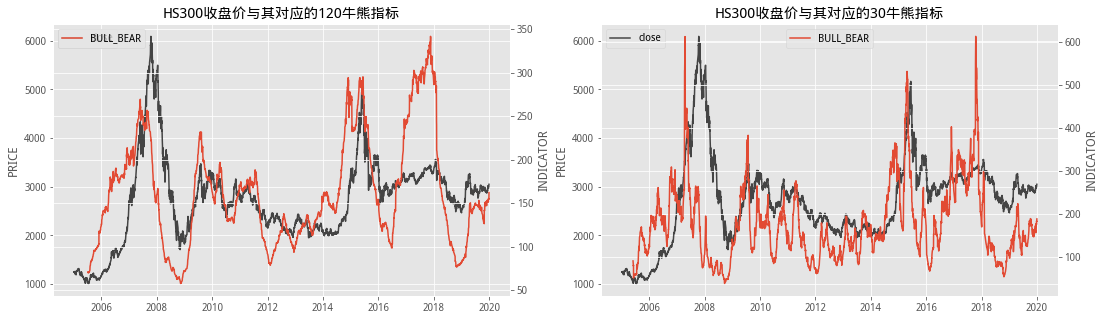

In [263]:
# 绘制指数价格与牛熊指标对比图
fig = plt.figure(figsize=(18, 5))

# 左图：收盘价 + 120期牛熊指标
ax = fig.add_subplot(1, 2, 1)
ax.set_title('HS300收盘价与其对应的120牛熊指标')
ax.plot(df['close'], color='black', alpha=0.7)
ax.legend(['close'], loc=2)
ax.set_ylabel('PRICE')

ax1 = ax.twinx()
ax1.plot(indicator_120)
ax1.legend(['BULL_BEAR'])
ax1.set_ylabel('INDICATOR')

# 右图：收盘价 + 30期牛熊指标
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title('HS300收盘价与其对应的30牛熊指标')
ax2.plot(df['close'], color='black', alpha=0.7)
ax2.legend(['close'], loc=2)
ax2.set_ylabel('PRICE')

ax3 = ax2.twinx()
ax3.plot(indicator_30)
ax3.legend(['BULL_BEAR'])
ax3.set_ylabel('INDICATOR')

plt.tight_layout()
plt.show()

# 借鉴双均线策略思想设计“直接牛熊”策略
所有择时模型均需经历参数寻优过程，而过拟合问题是量化模型必须研究并加以克服的核心难点。直接牛熊择时策略在参数选取环节采用宽范围网格搜索方式，该策略包含两个核心参数，分别对应短期牛熊指标与长期牛熊指标的计算窗口长度。具体实施过程中，短期窗口长度参数的测试区间设定为30日至60日，测试间隔为5日；长期窗口长度参数的测试区间设定为120日至250日，测试间隔为10日。策略评价过程中，采用夏普比率作为核心评价指标，对不同参数组合下的策略表现进行衡量，同时针对该参数选取方法开展过拟合测试。

本次过拟合测试采用基于组合对称交叉验证（CSCV）框架计算策略过拟合概率（PBO）的方法，该方法是检验过拟合现象的有效手段。其核心逻辑并非验证单个参数是否存在过拟合，而是判断某类策略所采用的参数选取方法是否易引发过拟合问题。具体应用到本策略中，CSCV框架主要用于测算直接牛熊策略所采用的网格寻优方法是否容易导致过拟合。在过拟合检验体系中，过拟合概率PBO的定义为：样本内最优参数在样本外的夏普比率排名处于后50%的概率。通常而言，当PBO概率低于50%时，可认为策略过拟合概率较低；PBO数值越小，表明策略回测过拟合的可能性越低。

## <font color=red>上证 50直接使用牛熊择时效果</font>
上证 50 对应的短期牛熊指标与长期牛熊指标最优窗口长度分别为 30 日和 140 日。从直接牛熊策略的过拟合检验图表可以观察到，在各类不同样本划分方式下，策略相对排名大多集中在 12.5% 附近；其中在将总样本进行 8 等分的划分方式下，策略过拟合概率 PBO 为 0.43%，可判定该策略过拟合风险处于较低水平。

In [286]:
# 网格参数寻优
symbol = '000016.XSHG'
start_date, end_date = '2005-06-01', '2019-12-31'

return_record = {}
annual_return_record = {}

short_windows = range(30, 61, 5)
long_windows = range(120, 251, 10)

for params in list(itertools.product(short_windows, long_windows)):
    fast_window = params[0]
    slow_window = params[1]
    
    # 初始化信号生成器
    signal_generator = BullBearSignalGenerator(symbol, start_date, end_date, fast_window, slow_window)
    
    # 生成交易信号
    signal_generator.generate_trade_signal()
    
    # 执行回测
    backtest = StrategyBacktestAnalyzer(signal_generator.raw_data['close'], signal_generator.trade_signal)
    
    # 记录收益数据
    return_record[f'{fast_window}-{slow_window}'] = backtest.strategy_daily_ret
    annual_return_record[f'{fast_window}-{slow_window}'] = backtest.calculate_strategy_metrics().loc['annual_return', 'strategy_nav']

2020-06-12 15:22:31,980 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:22:31,980 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:22:36,208 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:22:36,208 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:22:40,501 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:22:40,501 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:22:44,902 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:22:44,902 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:22:49,322 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:22:49,322 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

...

2020-06-12 15:24:44,635 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:24:44,635 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:24:48,904 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:24:48,904 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:24:53,101 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:24:53,101 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:24:57,416 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:24:57,416 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 15:25:01,594 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 15:25:01,594 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

获取w: 100%|██████████| 924/924 [00:27<00:00, 33.39it/s]


年化收益最优参数:30-140
6等分情况下,过拟合概率为0.0
8等分情况下,过拟合概率为0.043
10等分情况下,过拟合概率为0.016
12等分情况下,过拟合概率为0.0


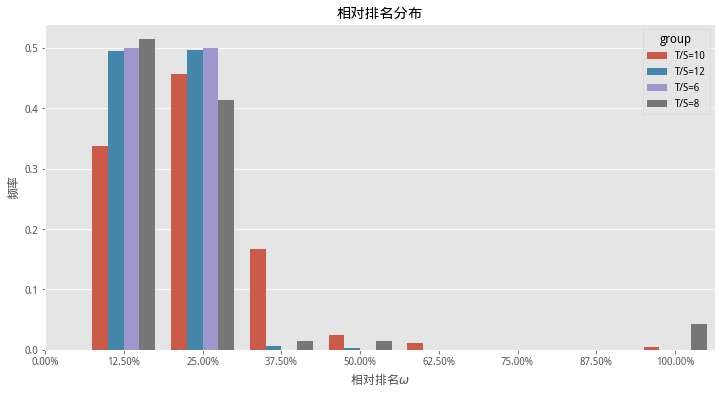

In [287]:
# 过拟合检测分析
ret_df = pd.concat(return_record, axis=1)

# 计算PBO与排名分布
w_dict, pbo_dict = compute_rank_and_pbo(ret_df, [6, 8, 10, 12])
df = pd.concat(w_dict, axis=1)

# 输出最优参数
best_param = max(annual_return_record, key=annual_return_record.get)
print('年化收益最优参数: %s' % best_param)

# 输出各分段下过拟合概率
for seg, pbo_val in pbo_dict.items():
    print(f'{seg}等分情况下, 过拟合概率为 {pbo_val:.2f}')

# 绘制分布直方图
plot_rank_distribution(df)

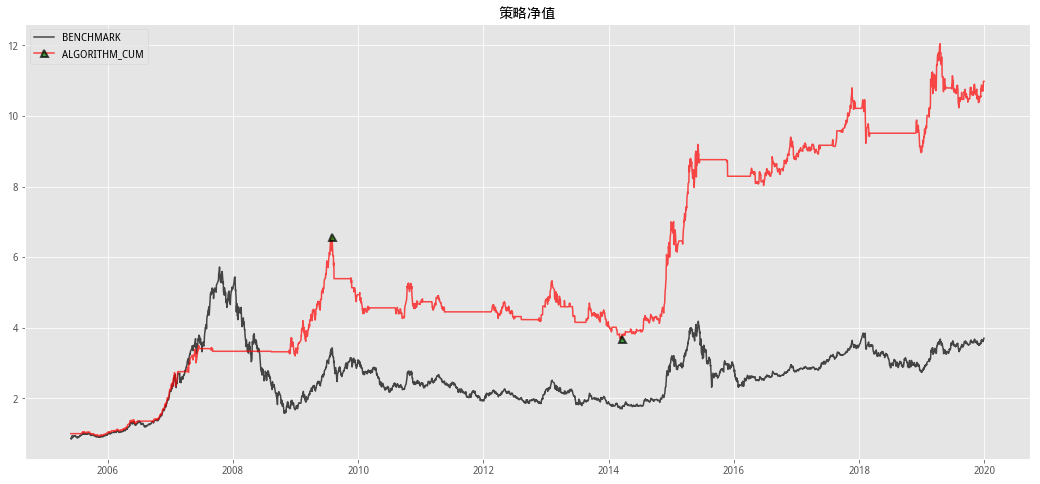

风险指标


,algorithm_cum,benchmark
annual_return,0.185432,0.108348
return_volatility,0.175086,0.276625
sharpe_ratio,0.066735,0.032162
max_drawdown,-0.440849,-0.724059
relative_return,0.077084,0.000000
relative_volatility,-0.101540,0.000000
relative_drawdown,0.283210,0.000000
info_ratio,0.238777,NaN
trade_count,56.000000,NaN
win_count,29.000000,NaN


分年度风险指标


,annual_return,return_volatility,sharpe_ratio,max_drawdown,relative_return,relative_volatility,relative_drawdown,info_ratio
2005,0.037920,0.121693,0.023075,-0.119448,-0.153566,-0.070165,5.134781e-16,-0.658122
2006,1.252986,0.196967,0.266340,-0.076151,-0.059139,-0.023116,5.471646e-02,-0.203119
2007,0.521547,0.232111,0.121346,-0.142361,-0.869729,-0.131681,5.788924e-02,-2.022755
2008,-0.003397,0.127653,0.002321,-0.138461,0.678683,-0.363963,5.713265e-01,1.339091
2009,0.460161,0.265214,0.098305,-0.277586,-0.355420,-0.062051,1.209357e-03,-0.845842
2010,-0.041675,0.176985,-0.009582,-0.146432,0.180565,-0.070625,1.469377e-01,0.615073
2011,-0.063260,0.086098,-0.045094,-0.094625,0.140505,-0.116977,1.826462e-01,0.626934
2012,0.081547,0.131696,0.041599,-0.118601,-0.090412,-0.062105,6.495998e-02,-0.378425
2013,-0.150064,0.205548,-0.043381,-0.241658,0.017152,-0.045282,4.426225e-02,0.053486
2014,0.749724,0.214092,0.171450,-0.087009,0.068540,-0.011108,-1.716042e-03,0.231370


In [288]:
# 初始化最优参数信号生成
signal_generator = BullBearSignalGenerator(symbol, start_date, end_date, 30, 140)

# 生成交易信号
signal_generator.generate_trade_signal()

# 执行策略回测
backtest = StrategyBacktestAnalyzer(signal_generator.raw_data['close'], signal_generator.trade_signal)

# 绘制净值曲线
backtest.plot_nav_trend()

# 输出风险指标与分年度绩效
backtest.risk_analysis

# 沪深300择时效果
沪深300指数对应的短期牛熊指标、长期牛熊指标的最优窗口长度，经网格搜索后确定分别为40日和130日。在对直接牛熊策略进行过拟合检验时，当总样本被划分为8等分时，该策略的过拟合概率PBO为0.5，处于一个较为尴尬的中间水平。

与上证50直接牛熊策略的表现类似，沪深300直接牛熊策略同样能够有效捕捉市场趋势：在2007年牛市行情中，可捕捉到大部分上涨行情；在2015年、2019年的两轮上涨行情中，也能实现较好的收益捕捉；即便在市场处于震荡整理阶段，该策略也能保持相对稳定的运行态势，实现缓慢的收益增长。

从策略绩效表现来看，沪深300直接牛熊策略的年化收益率达到20%，整体表现较为优异。但需要重点关注的是，该策略的过拟合概率相对较高，这意味着在实际市场环境中，该策略存在较高的失效风险，后续需进一步优化参数以降低过拟合可能性。

In [264]:
# 网格参数寻优
symbol = '000300.XSHG'
start_date, end_date = '2005-06-01', '2019-12-31'

return_record = {}
annual_return_record = {}

short_windows = range(30, 61, 5)
long_windows = range(120, 251, 10)

for params in list(itertools.product(short_windows, long_windows)):
    fast_window = params[0]
    slow_window = params[1]
    
    # 初始化信号生成器
    signal_generator = BullBearSignalGenerator(symbol, start_date, end_date, fast_window, slow_window)
    
    # 生成交易信号
    signal_generator.generate_trade_signal()
    
    # 执行回测
    backtest = StrategyBacktestAnalyzer(signal_generator.raw_data['close'], signal_generator.trade_signal)
    
    # 记录收益数据
    return_record[f'{fast_window}-{slow_window}'] = backtest.strategy_daily_ret
    annual_return_record[f'{fast_window}-{slow_window}'] = backtest.calculate_strategy_metrics().loc['annual_return', 'strategy_nav']

2020-06-12 13:33:35,514 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:33:35,514 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:33:39,667 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:33:39,667 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:33:43,910 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:33:43,910 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:33:48,303 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:33:48,303 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:33:52,708 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:33:52,708 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

...

2020-06-12 13:35:52,832 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:35:52,832 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:35:56,956 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:35:56,956 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:36:01,237 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:36:01,237 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:36:05,621 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:36:05,621 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

2020-06-12 13:36:09,913 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg'])
Exception: 抱歉，您每分钟最多访问该接口60次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
2020-06-12 13:36:09,913 TuShare <ipython-input-12-118d3fe8324f>:91 wrapper ERROR TuShare exec trade_cal failed, args:(), kwargs:{'exchange': 'SSE', 'start_date': '20050104', 'end_date': '20191231'}, try again.
Traceback (most recent call last):
  File "<ipython-input-12-118d3fe8324f>", line 85, in wrapper
    return m(*args, **kwargs)
  File "/opt/conda/lib/python3.6/site-packages/tushare/pro/client.py", line 43, in query
    raise Exception(result['msg

获取w: 100%|██████████| 924/924 [00:13<00:00, 70.42it/s]


年化收益最优参数:40-130
6等分情况下,过拟合概率为0.65
8等分情况下,过拟合概率为0.5
10等分情况下,过拟合概率为0.61
12等分情况下,过拟合概率为0.55


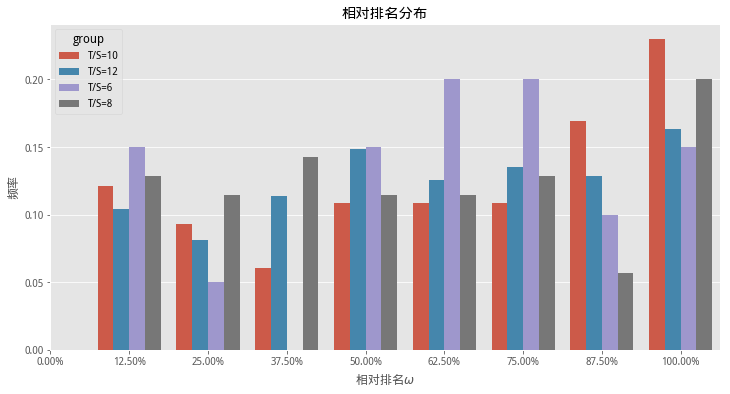

In [283]:
# 过拟合检测分析
ret_df = pd.concat(return_record, axis=1)

w_dict, pbo_dict = compute_rank_and_pbo(ret_df, [6, 8, 10, 12])
df = pd.concat(w_dict, axis=1)

best_param = max(annual_return_record, key=annual_return_record.get)
print('年化收益最优参数: %s' % best_param)

for key, val in pbo_dict.items():
    print(f'{key}等分情况下, 过拟合概率为 {val:.2f}')

plot_rank_distribution(df)

使用最优参数回测40-130进行回测

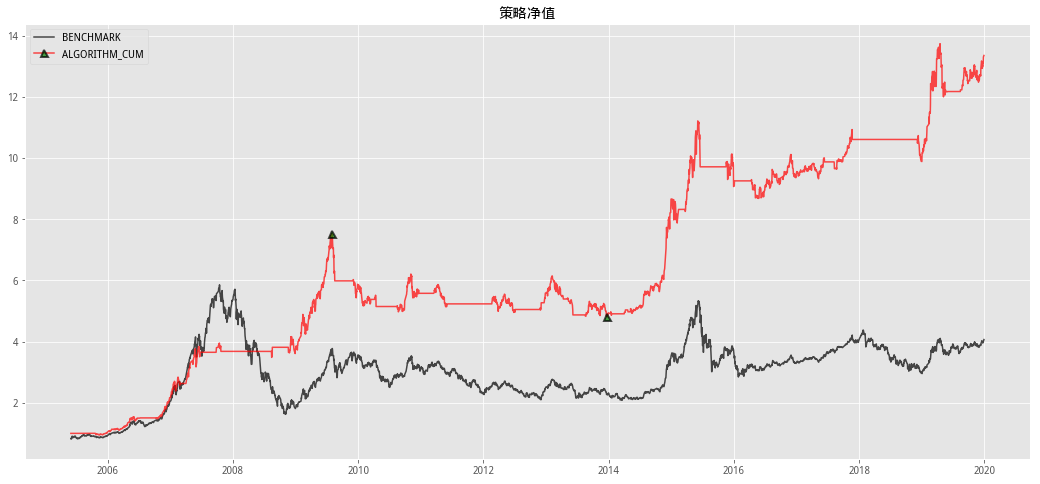

风险指标


,algorithm_cum,benchmark
annual_return,0.202006,0.118991
return_volatility,0.173631,0.274489
sharpe_ratio,0.072269,0.034491
max_drawdown,-0.361405,-0.723038
relative_return,0.083015,0.000000
relative_volatility,-0.100858,0.000000
relative_drawdown,0.361633,0.000000
info_ratio,0.259523,NaN
trade_count,45.000000,NaN
win_count,30.000000,NaN


分年度风险指标


,annual_return,return_volatility,sharpe_ratio,max_drawdown,relative_return,relative_volatility,relative_drawdown,info_ratio
2005,0.061052,0.082337,0.047920,-0.055167,-0.121191,-0.127314,0.062737,-0.531633
2006,1.131128,0.190871,0.256075,-0.085010,-0.122433,-0.031858,0.053145,-0.426543
2007,0.734688,0.279514,0.133180,-0.157585,-0.962108,-0.089257,0.051435,-2.080338
2008,0.016182,0.162112,0.011297,-0.132929,0.688949,-0.323224,0.583082,1.356732
2009,0.528549,0.266434,0.108801,-0.277811,-0.416067,-0.059123,-0.025169,-1.007909
2010,-0.049464,0.186906,-0.011188,-0.145255,0.070579,-0.064732,0.149744,0.229226
2011,-0.064097,0.075130,-0.053164,-0.123820,0.208810,-0.130846,0.192605,0.943417
2012,0.070434,0.125840,0.038018,-0.107459,-0.031325,-0.077883,0.116595,-0.130901
2013,-0.130172,0.172265,-0.045582,-0.218257,-0.048502,-0.050407,0.003337,-0.173791
2014,0.791854,0.164097,0.229269,-0.048342,0.248905,-0.028772,0.048853,0.994926


In [289]:
# 最优参数回测与结果展示
signal_generator = BullBearSignalGenerator(symbol, start_date, end_date, 40, 130)
signal_generator.generate_trade_signal()

backtest = StrategyBacktestAnalyzer(signal_generator.raw_data['close'], signal_generator.trade_signal)

backtest.plot_nav_trend()
backtest.risk_analysis